# **Error Analysis - All Beauty**


Note: the predictions get retourned as BPR loss. As consequence, the predictions are not in the range of 0 to 1. To interpret them further, we need to convert them to the range of 0 to 1. Use sigmoid function.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx

In [71]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_ego_hops(G, center_node, hops=2):
    """
    Draw the subgraph of G containing center_node plus all nodes
    at distance ≤ hops (first- and second-degree neighbors).
    """
    # 1) compute distances up to `hops`
    lengths = nx.single_source_shortest_path_length(G, center_node, cutoff=hops)
    # `lengths` maps node → distance (0 for center, 1 for neighbors, 2 for 2-hop)
    
    # 2) induce the subgraph
    nodes_within = list(lengths.keys())
    H = G.subgraph(nodes_within).copy()
    
    # 3) draw
    pos = nx.spring_layout(H)  # force-directed layout
    plt.figure(figsize=(8,8))
    
    # draw nodes, coloring by distance
    node_colors = [lengths[n] for n in H.nodes()]
    nx.draw_networkx_nodes(
        H, pos,
        node_size=300,
        cmap=plt.cm.viridis,
        node_color=node_colors,
        vmin=0, vmax=hops
    )
    # highlight edges connected to center node
    center_edges = list(H.edges(center_node))
    nx.draw_networkx_edges(
        H, pos,
        edgelist=center_edges,
        width=2.5,
        alpha=0.8,
        edge_color='red'
    )
    # draw edges
    nx.draw_networkx_edges(H, pos, alpha=0.5)
    
    # highlight the center node with a red border
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=[center_node],
        node_size=500,
        edgecolors='red',
        linewidths=2,
    )
    
    # labels - adjust font size and add bbox for better readability
    labels = nx.draw_networkx_labels(
        H, pos,
        font_size=8,
        font_weight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
        horizontalalignment='center'
    )
    
    plt.title(f"Ego-graph of {center_node} (hops≤{hops})")
    plt.axis('off')
    plt.show()

# test use sigmoid function
def process_prediction(prediction_df):
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    prediction_df["prediction_sigmoid"] = sigmoid(prediction_df['prediction'])
    prediction_df["prediction_value"] = (prediction_df["prediction_sigmoid"] > 0.5).astype(int) # 1 if sigmoid > 0.5, otherwise 0
    return prediction_df

def count_hits(error_df):
    """
    Count hits and calculate accuracy metrics for prediction results.
    
    Args:
        error_df: DataFrame containing prediction results with 'prediction_value' and 'actual' columns
        
    Returns:
        DataFrame: The input DataFrame with additional columns for prediction metrics
    """
    # Add prediction correctness column
    error_df["prediction_correct"] = error_df["prediction_value"] == error_df["actual"]
    
    # Add positive and negative prediction columns
    error_df["prediction_positive"] = error_df["prediction_value"] == 1
    error_df["prediction_negative"] = error_df["prediction_value"] == 0

    
    # Print accuracy
    print(f"Accuracy in test set: {error_df['prediction_correct'].sum() / len(error_df)}")
    
    return error_df

def connect_parents(error_df, relation_df):
    error_df_item = error_df.copy()
    
    # merge first level parent
    error_df_item = error_df_item.merge(relation_df, left_on="item_id", right_on="head", how="left").rename(columns={"tail":"first_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)
    
    # merge second level parent
    error_df_item = error_df_item.merge(relation_df, left_on="first_level_parent", right_on="head", how="left").rename(columns={"tail":"second_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)
    
    # merge third level parent
    error_df_item = error_df_item.merge(relation_df, left_on="second_level_parent", right_on="head", how="left").rename(columns={"tail":"third_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)

    # merge fourth level parent
    error_df_item = error_df_item.merge(relation_df, left_on="third_level_parent", right_on="head", how="left").rename(columns={"tail":"fourth_level_parent"})
    error_df_item.drop(columns=["head","relation","Unnamed: 0"], inplace=True)

    return error_df_item


def map_ids_to_entities(df, mapping_df, df_type:str):
    if df_type == "relation":
        df["head"] = df["head"].map(mapping_df.set_index("id")["entity"])
        df["tail"] = df["tail"].map(mapping_df.set_index("id")["entity"])
    elif df_type == "error":
        df["item_id"] = df["item_id"].map(mapping_df.set_index("id")["entity"])
        df["user_id"] = df["user_id"].map(mapping_df.set_index("id")["entity"])
    return df


## **2. All Beauty**

### **2.1 Baseline (KGIL)**

In [72]:
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[1]
MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
MODEL_TECHNIQUE = MODEL_TECHNIQUES[5]
MODEL_TECHNIQUE_NAME = MODEL_TECHNIQUE.replace("/", "_")

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"
EXPERIMENT_DATA_PATH = os.path.join(project_root,"experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

METADATA_PATH = os.path.join(project_root, 'preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'taxonomy',DATASET)

baseline_error = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv")
baseline_mapping = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
baseline_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_relations.csv")
df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

In [73]:
baseline_mapping

,entity,id
0,AFSKPY37N3C43SOI5IEXEK5JSIYA,0
1,AHV6QCNBJNSGLATP56JAWJ3C4G2A,1
2,AFJBKPK5W56XWSNPQU2WW66ISWYQ,2
3,AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,3
4,AFWVN52MRBWOTIK7UGXBWGOY4HBA,4
...,...,...
571,B09G22586Y,571
572,B0BVQQ58G8,572
573,B0B4MR9BXN,573
574,B08HVRP54L,574


In [74]:

baseline_error = map_ids_to_entities(baseline_error, baseline_mapping,"error")
baseline_relation = map_ids_to_entities(baseline_relation, baseline_mapping,"relation")
baseline_relation

,Unnamed: 0,head,relation,tail
0,0,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07J3GH1W1
1,1,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07W397QG4
2,2,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07KG1TWP5
3,3,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B08JTNQFZY
4,4,AFSKPY37N3C43SOI5IEXEK5JSIYA,0,B07SLFWZKN
...,...,...,...,...
2254,2254,AGQIUTI7M4XUGCRV6E66FAOCX5PQ,0,B08DK5D9J5
2255,2255,AGOLMT3QETKYNESRYKBA6D7XXS7A,0,B0BVQQ58G8
2256,2256,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,0,B0BVQQ58G8
2257,2257,AEMP3A7IKW37CMWFXNKXWW6HGJHA_1,0,B0B4MR9BXN


Since we evalute the kg model on the top K ranking metrics ndcg@20 and recall@20 we use the BPR prediction to filter out the Top @K items for each user.

In [75]:
baseline_error_at_k = baseline_error.sort_values(by=["user_id","prediction"], ascending=True)
# keep only top 20 entries for each user
baseline_error_at_k = baseline_error_at_k.groupby("user_id").tail(20)
baseline_error_at_k

,user_id,item_id,prediction,actual
3202,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08SG2MBRY,1.059312,0
3322,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B01M24DUXH,1.063506,0
3005,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,AHSP5IKX6USXFMSHWDQMXSKAEJ3Q,1.094380,0
3158,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08PLFZB89,1.095301,0
3185,AE3PLZHW6NXWBMZ76TDVFQG2MJFA,B08SBV6Z57,1.111297,0
...,...,...,...,...
8735,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,AF2AJZ2KIDH4QJSOXBKCFGAZITGA,1.309137,0
9091,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B09L33VJCL,1.400074,0
8994,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B0844X21MJ,1.525948,0
9073,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B08P5579KC,1.611211,0


In [76]:
print("Actual values in test set: ",baseline_error_at_k["actual"].value_counts())
baseline_error_at_k = process_prediction(baseline_error_at_k)
baseline_error_at_k = count_hits(baseline_error_at_k)
print(f"Accuracy in test set: {baseline_error_at_k['prediction_correct'].sum() / len(baseline_error_at_k)}")

Actual values in test set:  actual
0    356
1      4
Name: count, dtype: int64
Accuracy in test set: 0.011111111111111112
Accuracy in test set: 0.011111111111111112


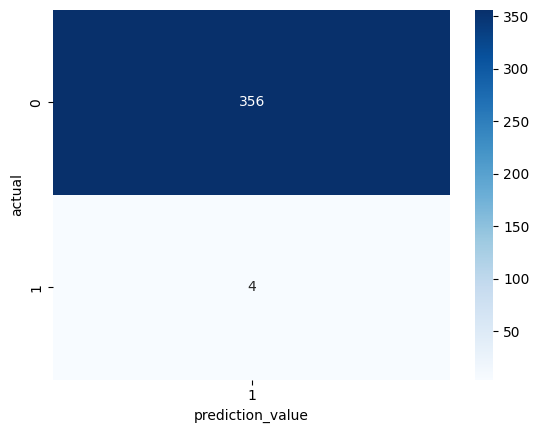

In [77]:
# confusion matrix
confusion_matrix_at_k = pd.crosstab(baseline_error_at_k["actual"], baseline_error_at_k["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix_at_k, annot=True, fmt="d", cmap="Blues")
plt.show()


The confusion matrix shows that the model is more likely to predict in the top 20 recommendations a wrong positive product than actually positive products. The accuracy is very low with just 1.1% correct predictions. 


In [78]:
baseline_error_test = baseline_error[baseline_error["user_id"].isin(df_test["user_id"])]
baseline_error_test = baseline_error_test[baseline_error_test["item_id"].isin(df_test["parent_asin"])]


In [79]:
print("Actual values in test set: ",baseline_error_test["actual"].value_counts())
baseline_error_test = process_prediction(baseline_error_test)
baseline_error_test = count_hits(baseline_error_test)


Actual values in test set:  actual
0    162
1     18
Name: count, dtype: int64
Accuracy in test set: 0.5166666666666667


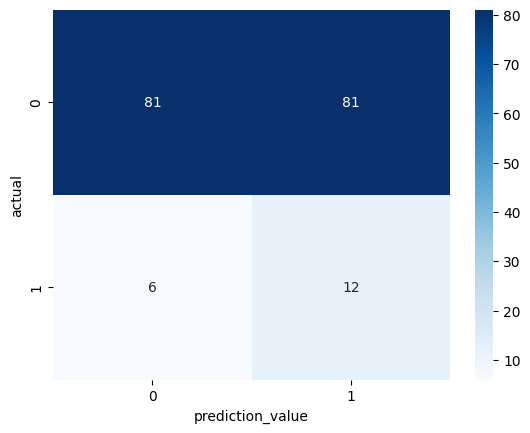

In [80]:
# confusion matrix
confusion_matrix_at_test = pd.crosstab(baseline_error_test["actual"], baseline_error_test["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix_at_test, annot=True, fmt="d", cmap="Blues")
plt.show()


The confusion matrix above displays all positive and negative predictions for the test set. The model is more likely to predict a negative hit (0) than a positive hit (1). The accuracy is moderate with 51.67% correct predictions. The likelihood of predicting a false positive is the same as predicting a true negative. Which indicates that the model is guessing. Meanwhile the correct true positive is double the amount of correct false negatives. Overall the distribution of the predictions is fairly balanced, which indicates that the model is not biased towards predicting positive or negative hits. On the other hand it indicates the model isnt able to learn the underlying patterns.


### **2.1 LLM-COL-HIERARCHY-TAX (gemma3)**

In [122]:
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[1]
MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]
MODEL_TECHNIQUE = MODEL_TECHNIQUES[3]
MODEL_TECHNIQUE_NAME = MODEL_TECHNIQUE.replace("/", "_")

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"
EXPERIMENT_DATA_PATH = os.path.join(project_root,"experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)
METADATA_PATH = os.path.join(project_root, 'preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'taxonomy',DATASET)

gemma_error = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv") # contains the predictions
gemma_mapping = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-triples.csv") # contains the relations between items and hierarhcy
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

In [123]:
gemma_error["user_id"] = gemma_error["user_id"].map(gemma_mapping.set_index("id")["entity"])
gemma_error["item_id"] = gemma_error["item_id"].map(gemma_mapping.set_index("id")["entity"])

#top 20 items for each user
gemma_error_at_k = gemma_error.sort_values(by=["user_id","prediction"], ascending=True)
gemma_error_at_k = gemma_error_at_k.groupby("user_id").tail(20)


In [124]:
print("Actual values in test set: ",gemma_error_at_k["actual"].value_counts())
gemma_error_at_k = process_prediction(gemma_error_at_k)
gemma_error_at_k = count_hits(gemma_error_at_k)

Actual values in test set:  actual
0    354
1      6
Name: count, dtype: int64
Accuracy in test set: 0.016666666666666666


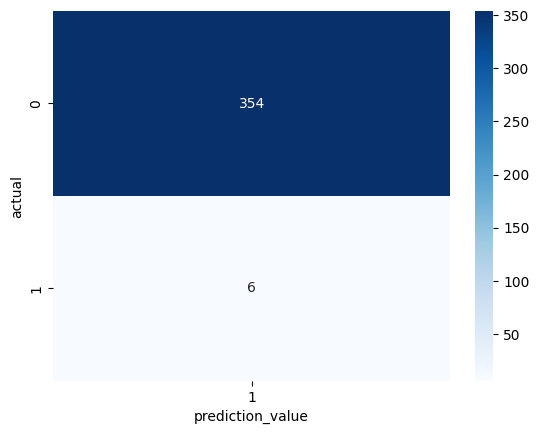

In [125]:
# confusion matrix
confusion_matrix_at_k = pd.crosstab(gemma_error_at_k["actual"], gemma_error_at_k["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix_at_k, annot=True, fmt="d", cmap="Blues")
plt.show()


The confusion matrix for the KG with the LLM-COL-HIERARCHY-TAX shows that the model is still more likely to predict in the top 20 recommendations a wrong positive product than actually positive products. The accuracy is very low with just 1.6% correct predictions. This is very small improvement compared to the baseline model.


In [126]:
gemma_error_test = gemma_error[gemma_error["user_id"].isin(df_test["user_id"])]
gemma_error_test = gemma_error_test[gemma_error_test["item_id"].isin(df_test["parent_asin"])]

print("Actual values in test set: ",gemma_error_test["actual"].value_counts())
gemma_error_test = process_prediction(gemma_error_test)
gemma_error_test = count_hits(gemma_error_test)

# confusion matrix

Actual values in test set:  actual
0    161
1     19
Name: count, dtype: int64
Accuracy in test set: 0.46111111111111114


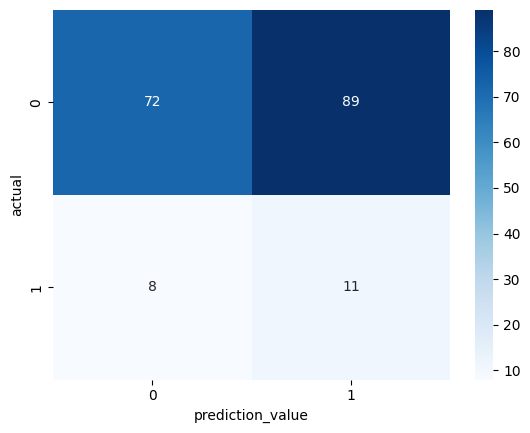

In [127]:
# confusion matrix
confusion_matrix = pd.crosstab(gemma_error_test["actual"], gemma_error_test["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


The KG with the LLM-COL-Hierarchy-Tax constructed by the LLM gemma3 shows for the user-item pairs in the test set a `low accuracy of 0.46`. Looking at the confusion matrix, we can see that the model is slighlty more likely to predict a true positive compared two a wrong negative. On the other hand this accuracy went down compared to the baseline model, which indicates that the LLM-COL-Hierarchy-Tax is worse able to learn the underlying patterns and might get confused by the the taxonomy. In total the model predicts 100 positive  and 80 negative item recommendations. Compared to the baseline model the positive predictions increased by 7. The model seems with the LLM-COL-Hierarchy-Tax to falsely understand user preferences.


To observe the errors and identify patterns we want to look for an item entity all the relations in the taxonomy that are connected to it.

In [132]:
gemma_error_item = gemma_error.copy()

gemma_error_item = connect_parents(gemma_error_item, gemma_relation)

gemma_error_item = process_prediction(gemma_error_item)
gemma_error_item = count_hits(gemma_error_item)

Accuracy in test set: 0.3046398046398046


In [129]:
gemma_error_item["fourth_level_parent"].value_counts()

Series([], Name: count, dtype: int64)

In [130]:
gemma_error_item.head()

,user_id,item_id,prediction,actual,first_level_parent,second_level_parent,third_level_parent,fourth_level_parent,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative
0,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFSKPY37N3C43SOI5IEXEK5JSIYA,0.081808,0,NaN,NaN,NaN,NaN,0.520441,1,False,True,False
1,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AHV6QCNBJNSGLATP56JAWJ3C4G2A,-0.021607,0,NaN,NaN,NaN,NaN,0.494599,0,True,False,True
2,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFJBKPK5W56XWSNPQU2WW66ISWYQ,0.085802,0,NaN,NaN,NaN,NaN,0.521437,1,False,True,False
3,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,0.011015,0,NaN,NaN,NaN,NaN,0.502754,1,False,True,False
4,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFWVN52MRBWOTIK7UGXBWGOY4HBA,-0.067471,0,NaN,NaN,NaN,NaN,0.483139,0,True,False,True


Taxonomy only three levels deep

In [142]:
df_train["item_id"] = df_train["parent_asin"]
df_train_parents = connect_parents(df_train, gemma_relation)

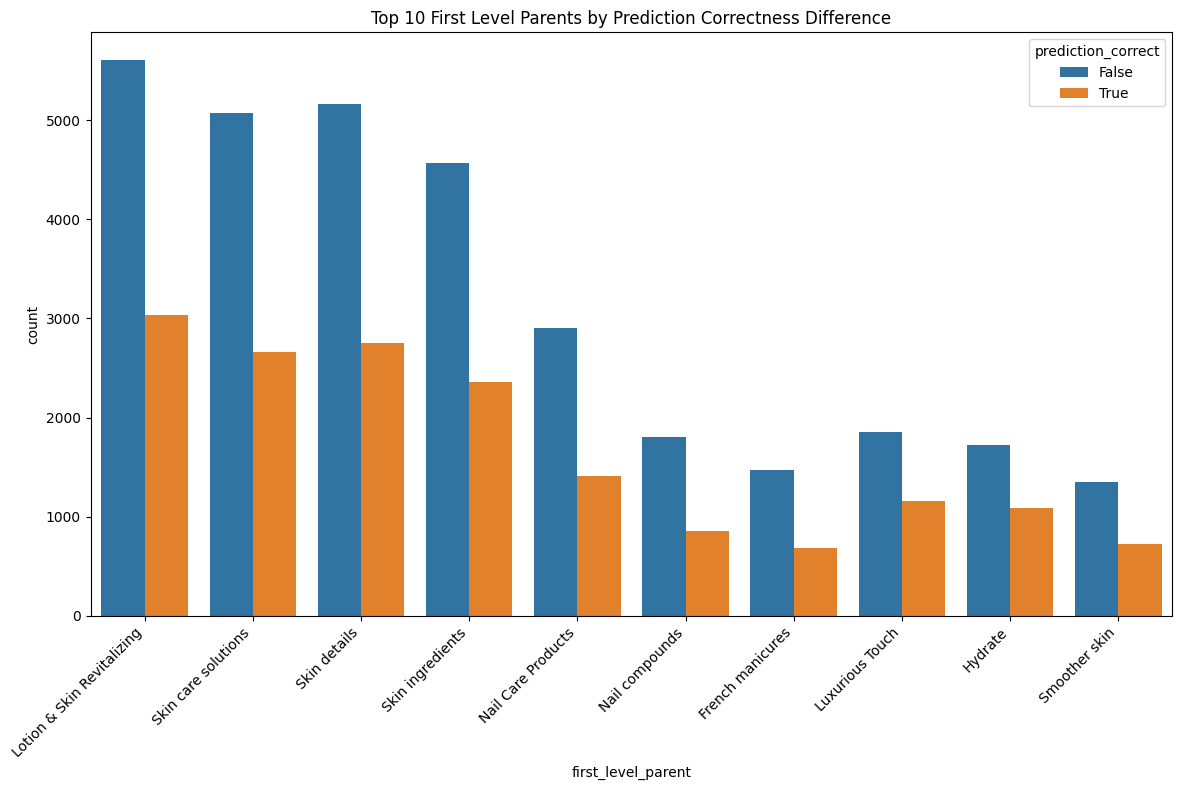

In [131]:
# Calculate counts for each combination of first_level_parent and prediction_correct
counts = gemma_error_item.groupby(['first_level_parent', 'prediction_correct']).size().unstack(fill_value=0)

# Ensure both True and False columns exist
if True not in counts.columns:
    counts[True] = 0
if False not in counts.columns:
    counts[False] = 0

# Calculate the absolute difference between True and False counts
counts['difference'] = abs(counts[True] - counts[False])

# Get the top 10 first_level_parent categories with the biggest difference
top_10_parents = counts.nlargest(10, 'difference').index

# Filter the original dataframe to include only these top 10 categories
filtered_data = gemma_error_item[gemma_error_item['first_level_parent'].isin(top_10_parents)]

# Plot the results for the top 10 categories
plt.figure(figsize=(12, 8))
plt.title("Top 10 First Level Parents by Prediction Correctness Difference")
plt.xlabel("first_level_parent")
plt.ylabel("count")
sns.countplot(x="first_level_parent", hue="prediction_correct",
              data=filtered_data, order=top_10_parents) # Order bars by difference magnitude
plt.xticks(rotation=45, ha='right') # Adjust rotation for readability
plt.tight_layout()
plt.show()

In [152]:
df_train_parents

,user_id,parent_asin,rating,timestamp,item_id,first_level_parent,second_level_parent,third_level_parent,fourth_level_parent
0,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,French manicures,Colors kit,NaN,NaN
1,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,French manicures,Dip powder,NaN,NaN
2,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,French manicures,Manicures home,NaN,NaN
3,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,Nail Care Products,Manicure home,NaN,NaN
4,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,Nail Care Products,Festive hues,NaN,NaN
...,...,...,...,...,...,...,...,...,...
36833,AG3GU5MHHM662AATYNDWYOKOZP7A,B086VYKNDF,5.0,1592523232806,B086VYKNDF,Popular gel,NaN,NaN,NaN
36834,AG3GU5MHHM662AATYNDWYOKOZP7A,B086VYKNDF,5.0,1592523232806,B086VYKNDF,Oil moisturizing,NaN,NaN,NaN
36835,AG3GU5MHHM662AATYNDWYOKOZP7A,B086VYKNDF,5.0,1592523232806,B086VYKNDF,Intensely moisturizing,NaN,NaN,NaN
36836,AG3GU5MHHM662AATYNDWYOKOZP7A,B086M8MZGB,4.0,1598889637062,B086M8MZGB,Dip powder,NaN,NaN,NaN


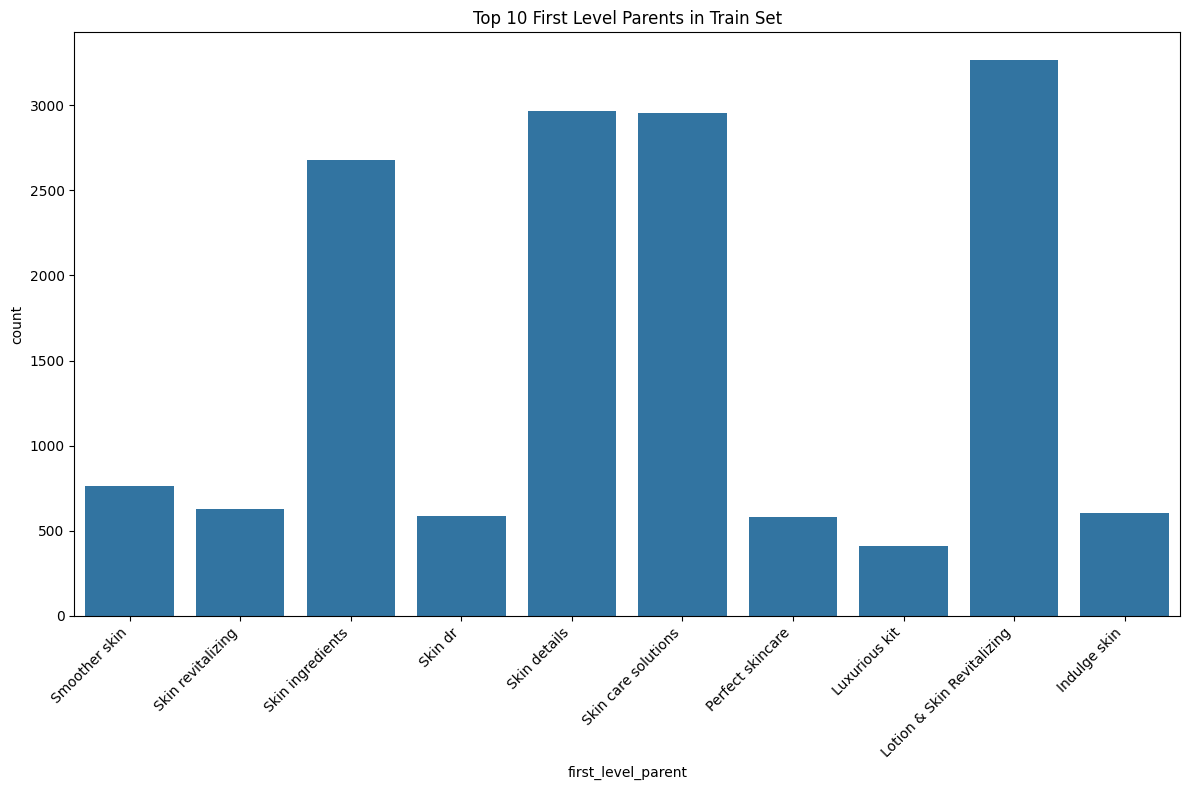

In [155]:

top_n = 10
# Count unique combinations of user_id, parent_asin, first_level_parent, then count first_level_parent occurrences
top_n_first_level_parents = df_train_parents[['user_id', 'parent_asin', 'first_level_parent']].drop_duplicates()['first_level_parent'].value_counts().nlargest(top_n).index
top_n_first_level_parents = top_n_first_level_parents.sort_values(ascending=False)
#plot the first level parents
plt.figure(figsize=(12, 8))

plt.title(f"Top {top_n} First Level Parents in Train Set")
plt.xlabel("first_level_parent")
plt.ylabel("count")
sns.countplot(x="first_level_parent", data=df_train_parents, order=top_n_first_level_parents)
plt.xticks(rotation=45, ha='right') # Adjust rotation for readability
plt.tight_layout()
plt.show()

In [159]:
# Convert the indices to sets for easier comparison
set_top_parents_first = set(top_n_first_level_parents)
set_top_n_first_level_parents_train = set(top_n_first_level_parents)

# Find the intersection
common_parents = set_top_parents_first.intersection(set_top_n_first_level_parents_train)

# Count the number of common parents
num_common_parents = len(common_parents)

print(f"Number of second_level_parents common between the top {top_n} by prediction difference and top {top_n} by frequency in train set: {num_common_parents}")
print("Common parents:", common_parents)


Number of second_level_parents common between the top 15 by prediction difference and top 15 by frequency in train set: 10
Common parents: {'Skin care solutions', 'Perfect skincare', 'Skin revitalizing', 'Skin ingredients', 'Smoother skin', 'Skin dr', 'Indulge skin', 'Skin details', 'Luxurious kit', 'Lotion & Skin Revitalizing'}


The plot above displays the counts of items in train set which are connected to the first level parents. It is interesting to observe that the related entities with the biggest difference between correct and incorrect predictions are mainly the most frequent first level parents. The top 4 products with the biggest prediciton difference are also the most represented first level parents in the train set, which indicates that the model is have a representation bias towards the most frequent first level parents. Never the less products associated with nail care, such as french manicures, nail care products and nail compounds have a huge difference in predictions, but are not underneat the most frequent first level parents.

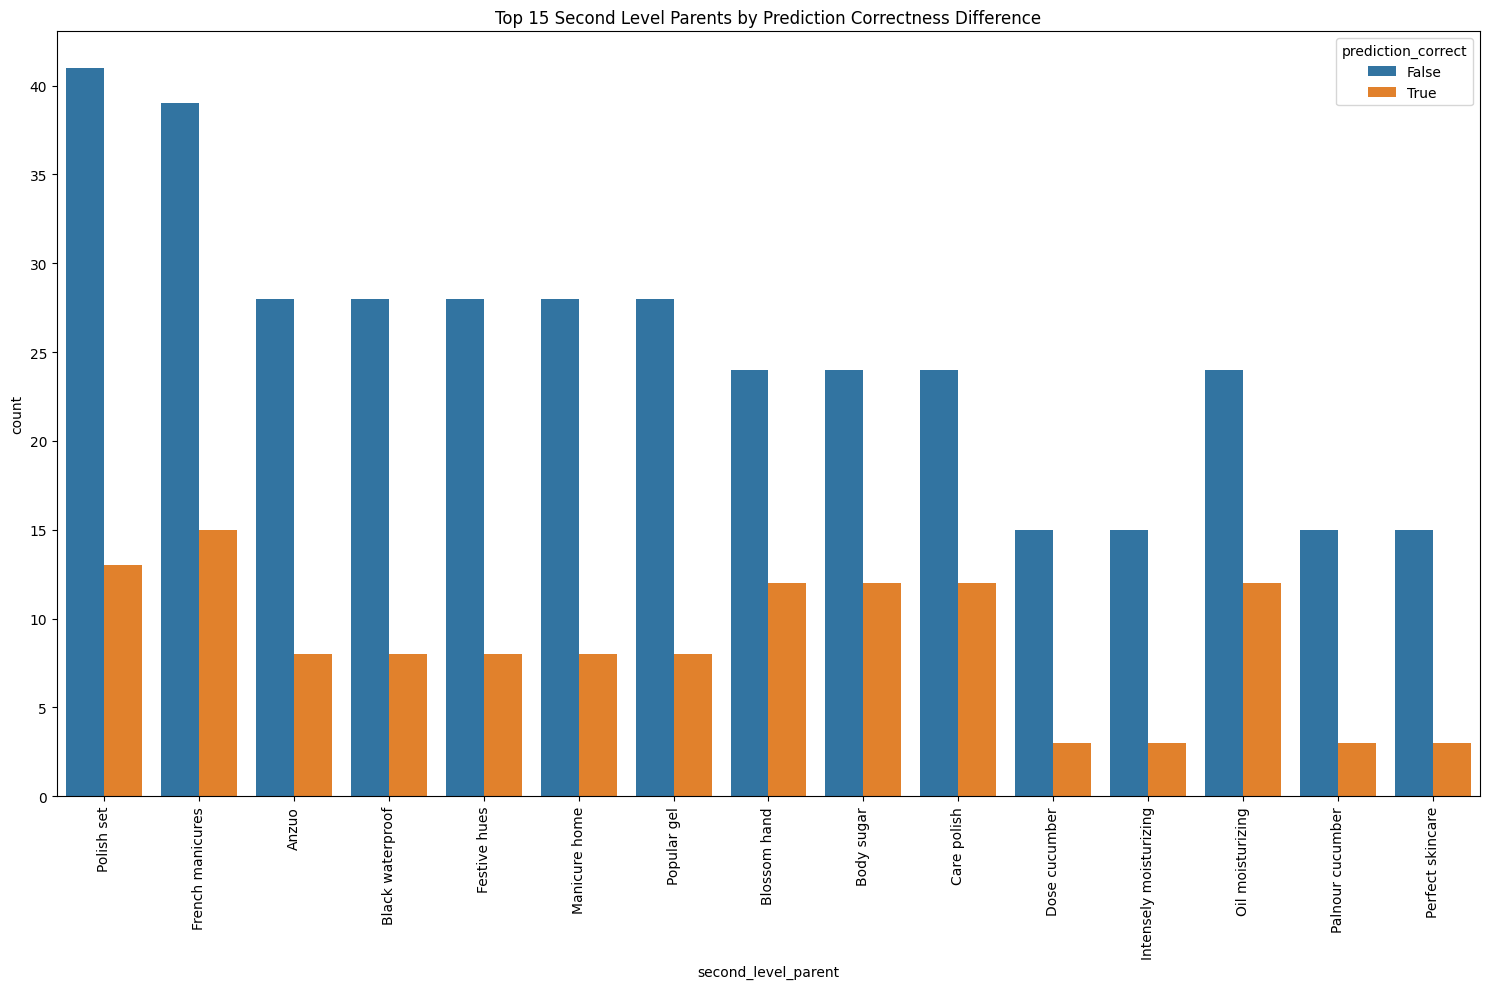

In [232]:
# Calculate counts for each combination of second_level_parent and prediction_correct
counts_second = gemma_error_item.groupby(['second_level_parent', 'prediction_correct']).size().unstack(fill_value=0)

# Ensure both True and False columns exist
if True not in counts_second.columns:
    counts_second[True] = 0
if False not in counts_second.columns:
    counts_second[False] = 0

# Calculate the absolute difference between True and False counts
counts_second['difference'] = abs(counts_second[True] - counts_second[False])

# Get the top N second_level_parent categories with the biggest difference (e.g., top 15)
top_n = 15
top_parents_second = counts_second.nlargest(top_n, 'difference').index

# Filter the original dataframe to include only these top N categories
filtered_data_second = gemma_error_item[gemma_error_item['second_level_parent'].isin(top_parents_second)]

# Plot the results for the top N categories
plt.figure(figsize=(15, 10)) # Adjust figure size if needed
plt.title(f"Top {top_n} Second Level Parents by Prediction Correctness Difference")
plt.xlabel("second_level_parent")
plt.ylabel("count")
sns.countplot(x="second_level_parent", hue="prediction_correct",
              data=filtered_data_second, order=top_parents_second) # Order bars by difference magnitude
plt.xticks(rotation=90) # Keep rotation for potentially long labels
plt.tight_layout()
plt.show()

In [233]:
df_train_parents

,user_id,parent_asin,rating,timestamp,item_id,first_level_parent,second_level_parent,third_level_parent,fourth_level_parent
0,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,French manicures,Colors kit,NaN,NaN
1,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,French manicures,Dip powder,NaN,NaN
2,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,French manicures,Manicures home,NaN,NaN
3,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,Nail Care Products,Manicure home,NaN,NaN
4,AFSKPY37N3C43SOI5IEXEK5JSIYA,B07J3GH1W1,5.0,1547589356557,B07J3GH1W1,Nail Care Products,Festive hues,NaN,NaN
...,...,...,...,...,...,...,...,...,...
36833,AG3GU5MHHM662AATYNDWYOKOZP7A,B086VYKNDF,5.0,1592523232806,B086VYKNDF,Popular gel,NaN,NaN,NaN
36834,AG3GU5MHHM662AATYNDWYOKOZP7A,B086VYKNDF,5.0,1592523232806,B086VYKNDF,Oil moisturizing,NaN,NaN,NaN
36835,AG3GU5MHHM662AATYNDWYOKOZP7A,B086VYKNDF,5.0,1592523232806,B086VYKNDF,Intensely moisturizing,NaN,NaN,NaN
36836,AG3GU5MHHM662AATYNDWYOKOZP7A,B086M8MZGB,4.0,1598889637062,B086M8MZGB,Dip powder,NaN,NaN,NaN


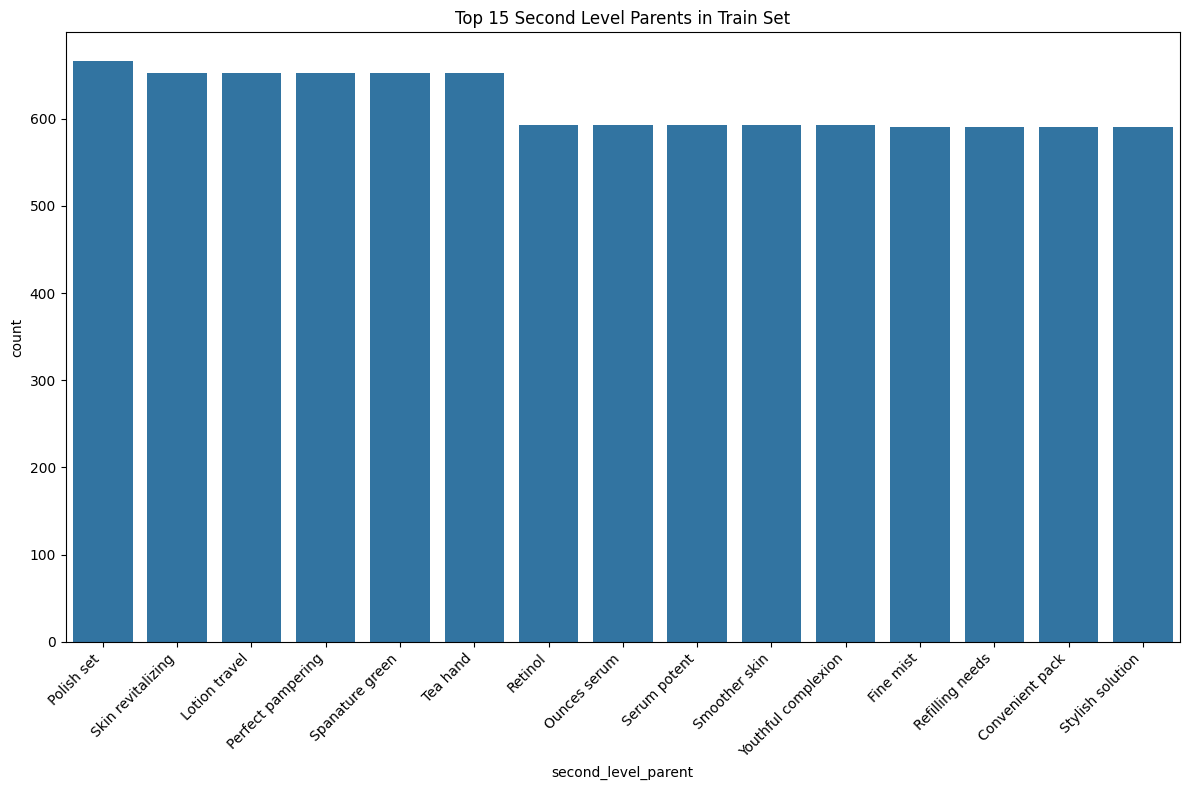

In [157]:

top_n = 15
top_n_second_level_parents = df_train_parents["second_level_parent"].value_counts().nlargest(top_n).index

#plot the first level parents
plt.figure(figsize=(12, 8))

plt.title(f"Top {top_n} Second Level Parents in Train Set")
plt.xlabel("second_level_parent")
plt.ylabel("count")
sns.countplot(x="second_level_parent", data=df_train_parents, order=top_n_second_level_parents)
plt.xticks(rotation=45, ha='right') # Adjust rotation for readability
plt.tight_layout()
plt.show()

In [158]:
# Convert the indices to sets for easier comparison
set_top_parents_second = set(top_parents_second)
set_top_n_second_level_parents_train = set(top_n_second_level_parents)

# Find the intersection
common_parents = set_top_parents_second.intersection(set_top_n_second_level_parents_train)

# Count the number of common parents
num_common_parents = len(common_parents)

print(f"Number of second_level_parents common between the top {top_n} by prediction difference and top {top_n} by frequency in train set: {num_common_parents}")
print("Common parents:", common_parents)


Number of second_level_parents common between the top 15 by prediction difference and top 15 by frequency in train set: 1
Common parents: {'Polish set'}


We see the same trend as for the first level parents. The model predicts a lot of values false for items related to manigure and nail items (e.g french manicure, polish set, etc.) or related to specific feature (e.g. ounces serum) wrong. 

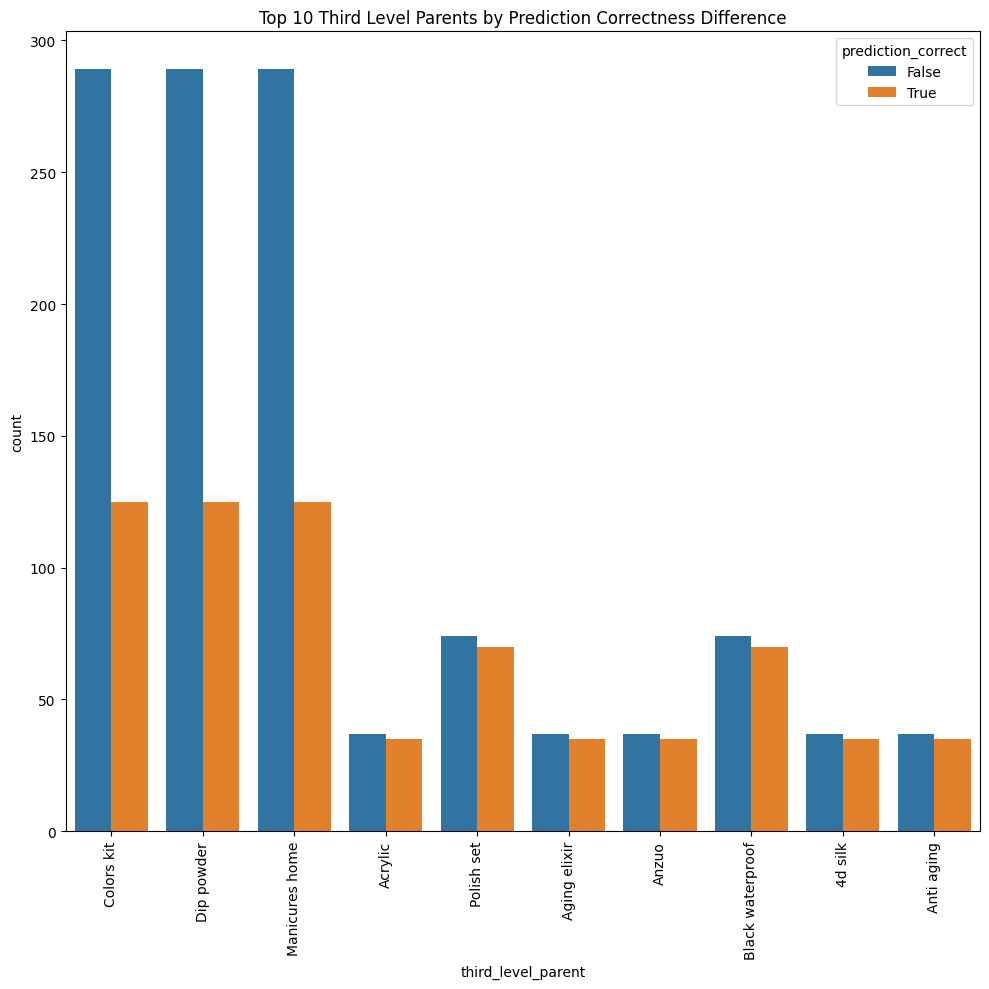

In [111]:
# third level parent
# Calculate counts for each combination of second_level_parent and prediction_correct
counts_third = gemma_error_item.groupby(['third_level_parent', 'prediction_correct']).size().unstack(fill_value=0)

# Ensure both True and False columns exist
if True not in counts_third.columns:
    counts_third[True] = 0
if False not in counts_third.columns:
    counts_third[False] = 0

# Calculate the absolute difference between True and False counts
counts_third['difference'] = abs(counts_third[True] - counts_third[False])

# Get the top N second_level_parent categories with the biggest difference (e.g., top 15)
top_n = 10
top_parents_third = counts_third.nlargest(top_n, 'difference').index
filtered_data_third = gemma_error_item[gemma_error_item['third_level_parent'].isin(top_parents_third)]

plt.figure(figsize=(10, 10))
plt.title("Top 10 Third Level Parents by Prediction Correctness Difference")
plt.xlabel("third_level_parent")
plt.ylabel("count")
sns.countplot(x="third_level_parent", hue="prediction_correct", data=filtered_data_third)
plt.xticks(rotation=90) # Keep rotation for potentially long labels
plt.tight_layout() # Apply tight layout similar to the previous plot
plt.show()

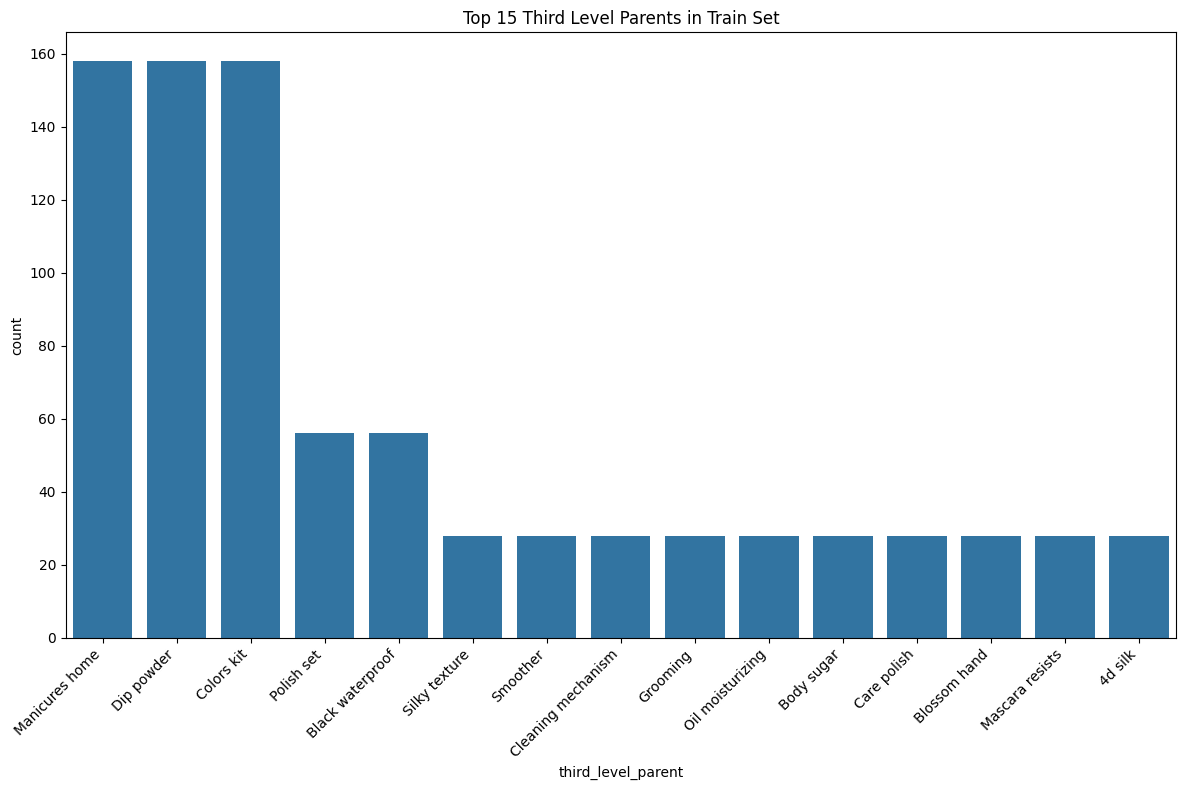

In [160]:

top_n = 15
top_n_third_level_parents = df_train_parents["third_level_parent"].value_counts().nlargest(top_n).index

#plot the first level parents
plt.figure(figsize=(12, 8))

plt.title(f"Top {top_n} Third Level Parents in Train Set")
plt.xlabel("third_level_parent")
plt.ylabel("count")
sns.countplot(x="third_level_parent", data=df_train_parents, order=top_n_third_level_parents)
plt.xticks(rotation=45, ha='right') # Adjust rotation for readability
plt.tight_layout()
plt.show()

In [183]:
# Convert the indices to sets for easier comparison
set_top_parents_third = set(top_parents_third)
set_top_n_third_level_parents_train = set(top_n_third_level_parents)

# Find the intersection
common_parents = set_top_parents_third.intersection(set_top_n_third_level_parents_train)

# Count the number of common parents
num_common_parents = len(common_parents)

print(f"Number of third_level_parents common between the top {top_n} by prediction difference and top {top_n} by frequency in train set: {num_common_parents}")
print("Common parents:", common_parents)


Number of third_level_parents common between the top 15 by prediction difference and top 15 by frequency in train set: 6
Common parents: {'4d silk', 'Dip powder', 'Polish set', 'Colors kit', 'Manicures home', 'Black waterproof'}


To understand the errors we look at the taxonomy graph created by the LLM-COL-HIERARCHY-TAX and see how items are connected to the taxonomy. This might help find suboptimal subgraphs, redundancies or issues with curtain depth of the taxonomy.

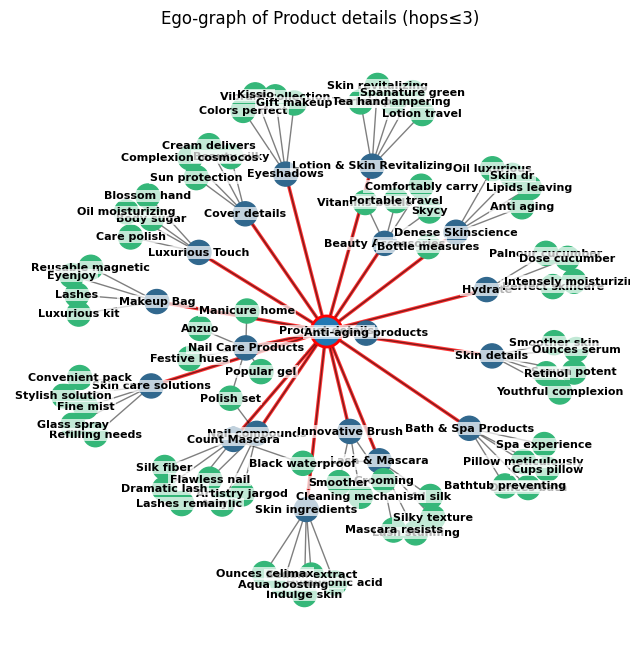

In [182]:
# plot the created taxonomy from LLM-COL-HIERARCHY-TAX
gemma_tax = gemma_relation[~gemma_relation["head"].str.startswith("B0") & ~gemma_relation["head"].str.startswith("A")]
g_tax = nx.from_pandas_edgelist(gemma_tax, source='head', target='tail')
draw_ego_hops(g_tax, center_node="Product details", hops=3)

Lets look at the subgraphs with high prediction errors: 
- Lotion & Skin Revitalizing
- Nail compounds

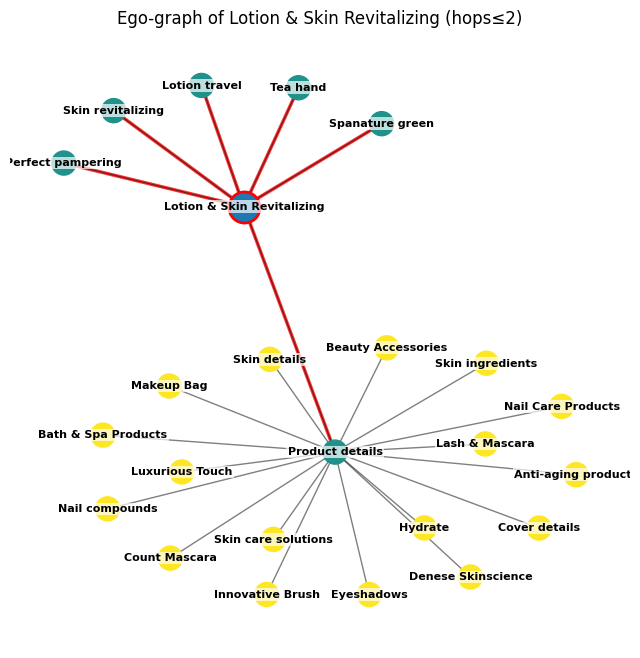

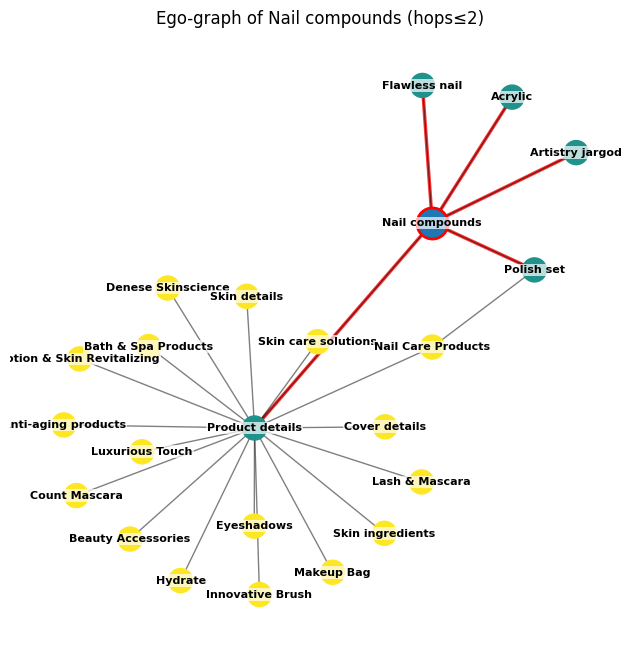

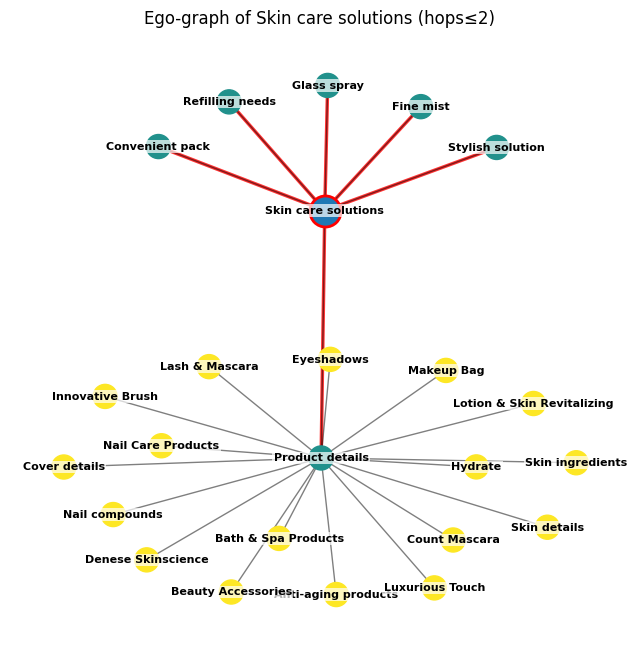

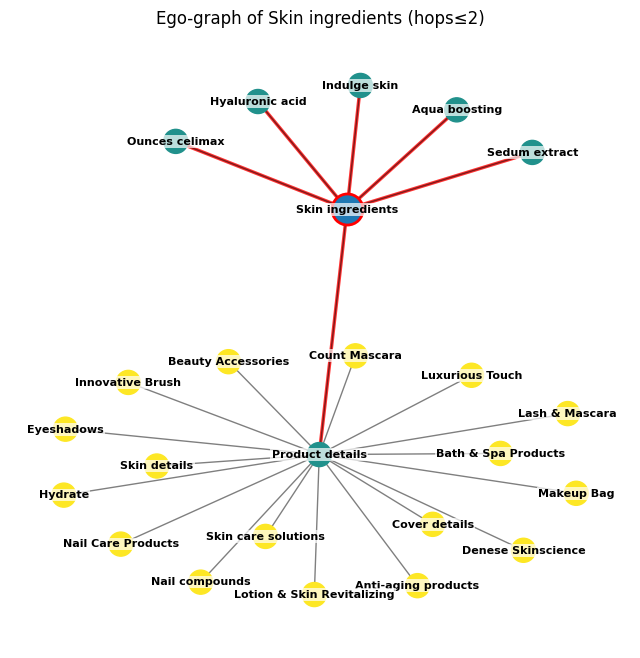

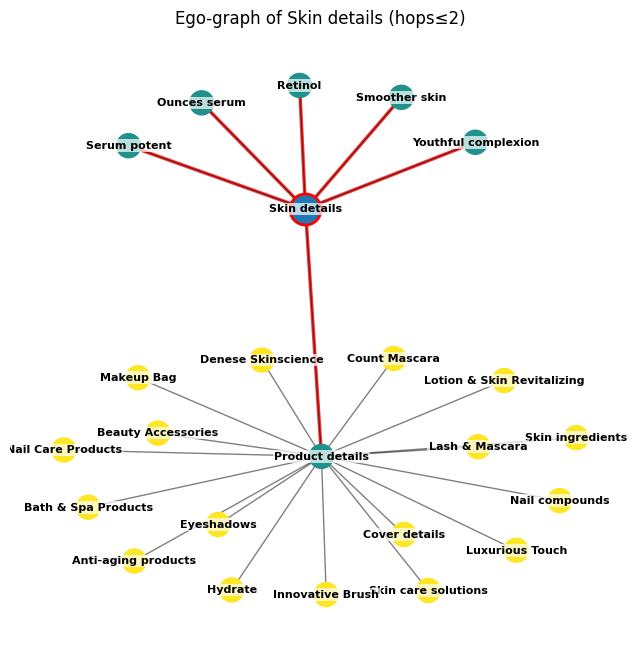

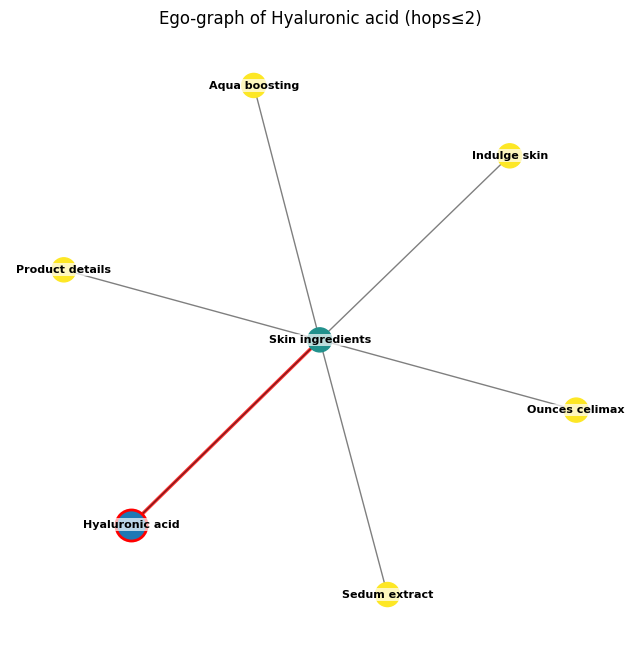

In [175]:
draw_ego_hops(g_tax, center_node="Lotion & Skin Revitalizing", hops=2)
draw_ego_hops(g_tax, center_node="Nail compounds", hops=2)
draw_ego_hops(g_tax, center_node="Skin care solutions", hops=2)
draw_ego_hops(g_tax, center_node="Skin ingredients", hops=2)
draw_ego_hops(g_tax, center_node="Skin details", hops=2)


First we observe that entities in taxonomies don't have relationships to multiple entities besides polish set. It is visible that the biggest difference between the prediction errors is in the second level parents of the taxonomy, which means most items are either only or both to the second level (grand parent) and the direct parent on the third level connected. This introduces a lot of redundancy in the taxonomy. Assumingly this could also have caused the prediciton errors based on popularities. If nearly all items are connected to their parent and grand parent and the grand parent is overrepresented in the train set, the model is more likely to predict positive for items related to the grand parent. Finer granularity without connection to grand parent could help find more distinct customer preferences. 

To prove the hypothesis we look at the items with the highest prediction errors and how they are connected to the taxonomy.

In [190]:
gemma_error

,user_id,item_id,prediction,actual
0,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFSKPY37N3C43SOI5IEXEK5JSIYA,0.081808,0
1,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AHV6QCNBJNSGLATP56JAWJ3C4G2A,-0.021607,0
2,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFJBKPK5W56XWSNPQU2WW66ISWYQ,0.085802,0
3,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,0.011015,0
4,AHTLWVDXSMG5YMVMEIWWOU6XBZMA,AFWVN52MRBWOTIK7UGXBWGOY4HBA,-0.067471,0
...,...,...,...,...
10723,AETJVSLQFY2F7D5AZ7H4ONORPQEQ_1,B093H28PD4,-0.053213,0
10724,AETJVSLQFY2F7D5AZ7H4ONORPQEQ_1,B09G22586Y,-0.042320,0
10725,AETJVSLQFY2F7D5AZ7H4ONORPQEQ_1,B0BVQQ58G8,-0.047803,0
10726,AETJVSLQFY2F7D5AZ7H4ONORPQEQ_1,B0B4MR9BXN,0.203677,0


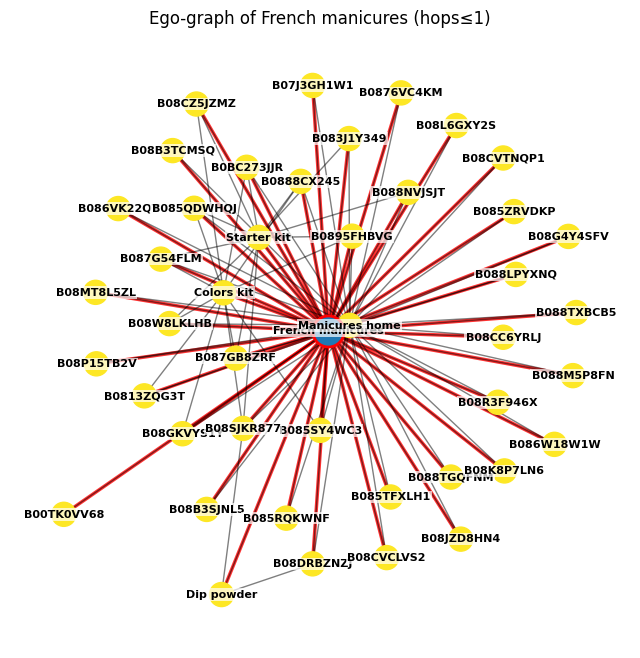

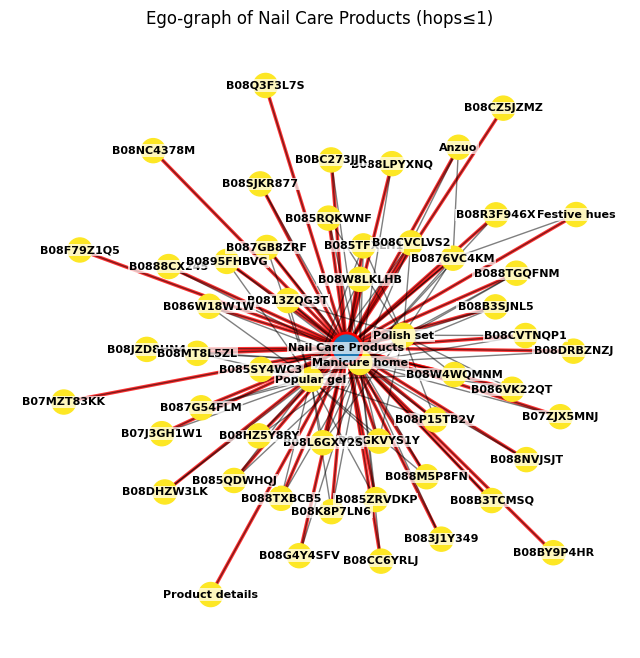

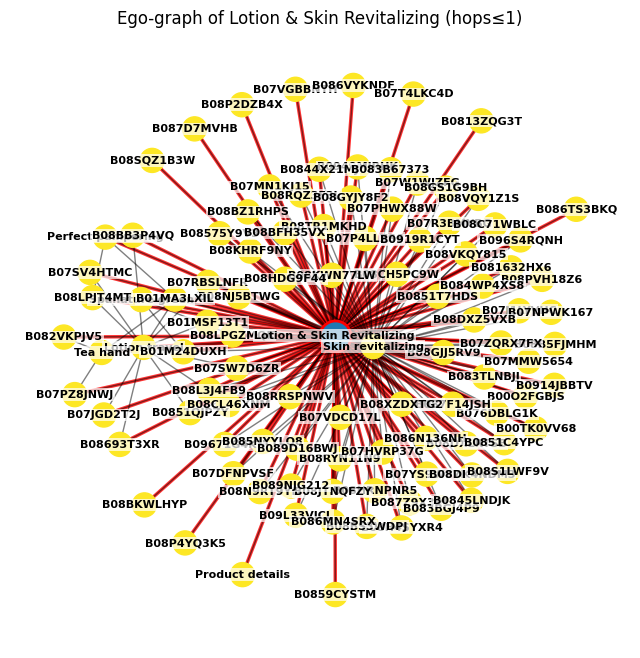

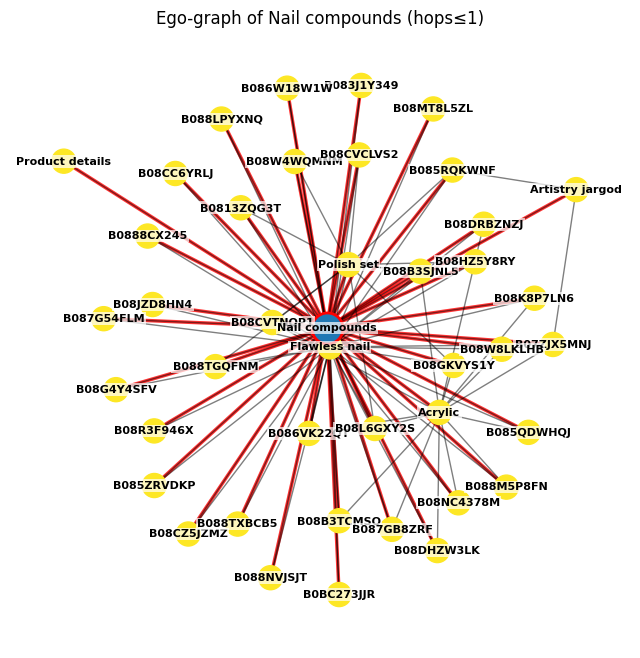

In [188]:
g_tax_error = nx.from_pandas_edgelist(gemma_relation, source='head', target='tail')
draw_ego_hops(g_tax_error, center_node="French manicures", hops=1)
draw_ego_hops(g_tax_error, center_node="Nail Care Products", hops=1)
draw_ego_hops(g_tax_error, center_node="Lotion & Skin Revitalizing", hops=1)
draw_ego_hops(g_tax_error, center_node="Nail compounds", hops=1)


In [209]:
gemma_relation[gemma_relation["tail"] == "French manicures"]

,Unnamed: 0,head,relation,tail
52,52,Starter kit,is parent of,French manicures
170,170,B088M5P8FN,related to,French manicures
306,306,B08K8P7LN6,related to,French manicures
348,348,B0888CX245,related to,French manicures
358,358,B085RQKWNF,related to,French manicures
453,453,B08B3TCMSQ,related to,French manicures
524,524,B087GB8ZRF,related to,French manicures
678,678,B08GKVYS1Y,related to,French manicures
704,704,B08P15TB2V,related to,French manicures
753,753,B083J1Y349,related to,French manicures


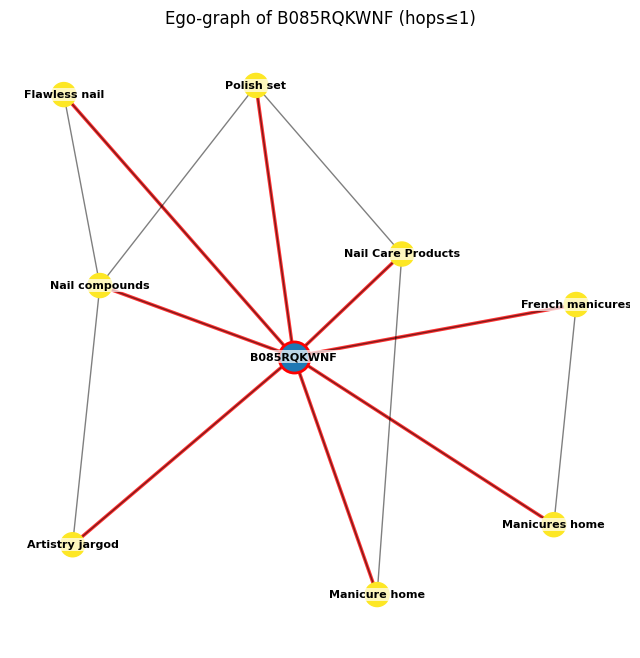

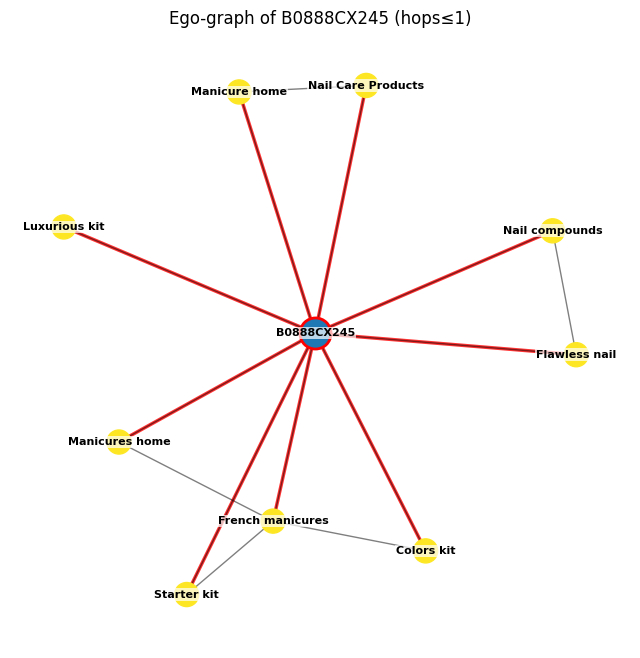

In [204]:
draw_ego_hops(g_tax_error, center_node="B085RQKWNF", hops=1)
draw_ego_hops(g_tax_error, center_node="B0888CX245", hops=1)

As visible we observe lot of redundant relationships between items and parents and grand parents in the subgraph for "Nail Care Products", "Nail compounds". 

In [206]:
gemma_relation[gemma_relation["tail"] == "Skin care solutions"]

,Unnamed: 0,head,relation,tail
16,16,Product details,is parent of,Skin care solutions
180,180,B0845LNDJK,related to,Skin care solutions
202,202,B089NJG212,related to,Skin care solutions
219,219,B083TLNBJJ,related to,Skin care solutions
232,232,B08BS3WDPJ,related to,Skin care solutions
...,...,...,...,...
2244,2244,B07MN1KJ15,related to,Skin care solutions
2269,2269,B084WP4XS8,related to,Skin care solutions
2335,2335,B01MA3LXIL,related to,Skin care solutions
2379,2379,B08GJJ5RV9,related to,Skin care solutions


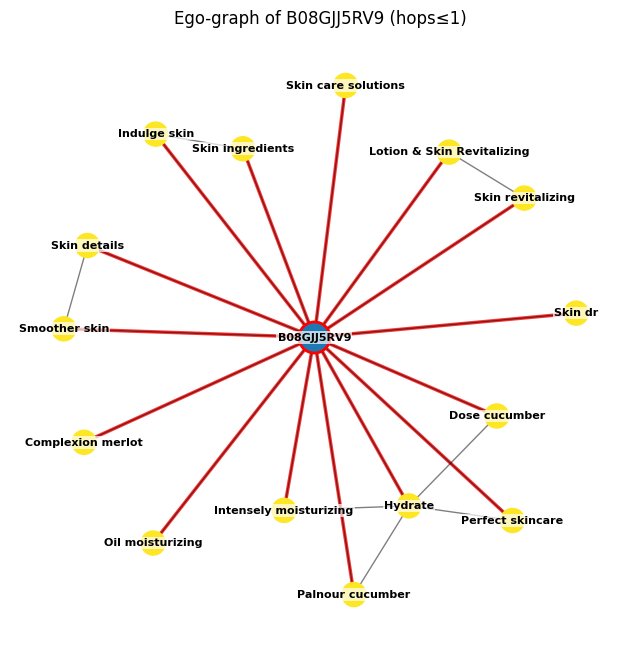

In [218]:
draw_ego_hops(g_tax_error, center_node="B08GJJ5RV9", hops=1)

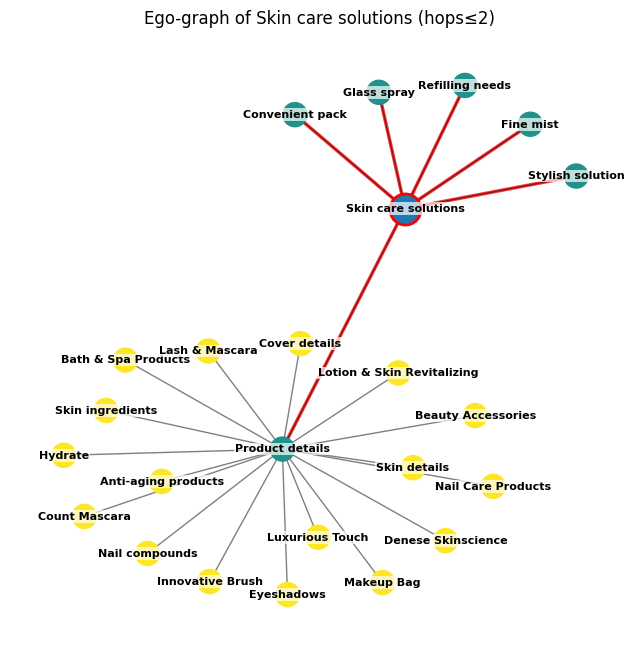

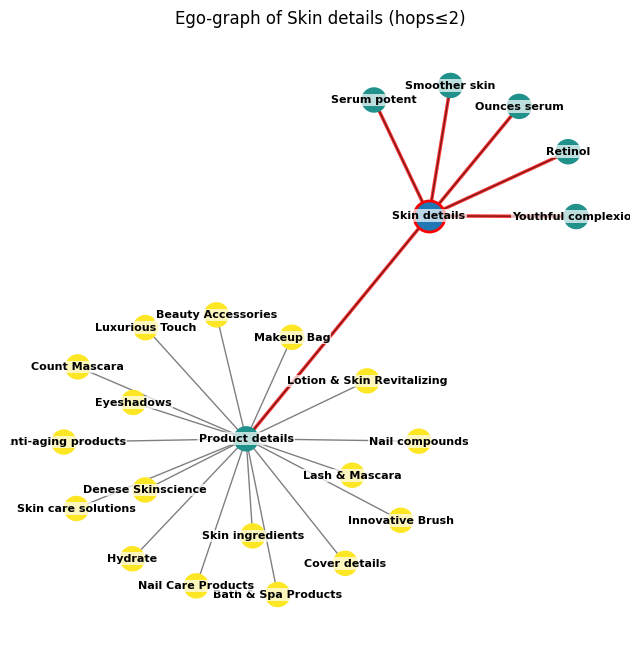

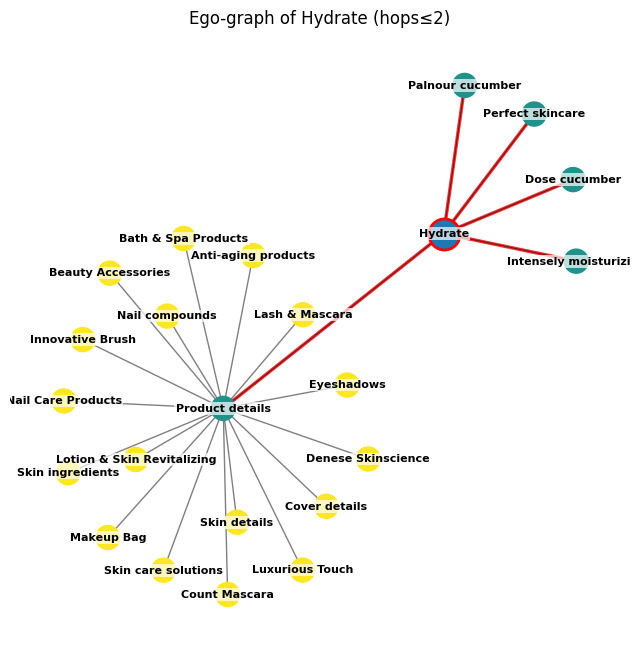

In [220]:
draw_ego_hops(g_tax, center_node="Skin care solutions", hops=2)
draw_ego_hops(g_tax, center_node="Skin details", hops=2)
draw_ego_hops(g_tax, center_node="Hydrate", hops=2)

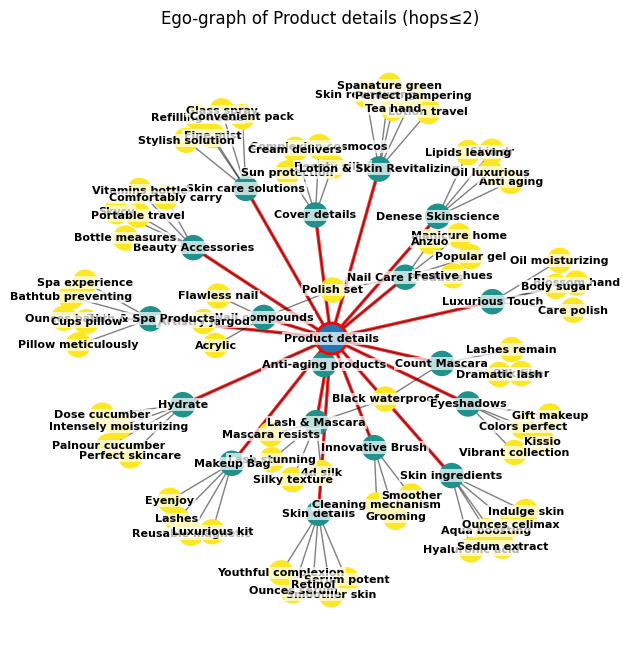

In [223]:
draw_ego_hops(g_tax, center_node="Product details", hops=2)

In [231]:
# count amount of items related to the grand parent and direct parent
gemma_relation_products = gemma_relation[gemma_relation["head"].str.startswith("B0") & ~gemma_relation["head"].str.startswith("A")]
print("# Items related to manicures home: ", len(gemma_relation_products[gemma_relation_products["tail"] == "Manicures home"]))
print("# Items related to french manicures: ", len(gemma_relation_products[gemma_relation_products["tail"] == "French manicures"]))

print("# Items related to skin care solutions: ", len(gemma_relation_products[gemma_relation_products["tail"] == "Lotion & Skin Revitalizing"]))
print("# Items related to skin details: ", len(gemma_relation_products[gemma_relation_products["tail"] == "Skin revitalizing"]))

print("# Items related to  nail compounds: ", len(gemma_relation_products[gemma_relation_products["tail"] == "Nail compounds"]))
print("# Items related to Flawless nail: ", len(gemma_relation_products[gemma_relation_products["tail"] == "Flawless nail"]))

print


# Items related to manicures home:  39
# Items related to french manicures:  39
# Items related to skin care solutions:  95
# Items related to skin details:  91
# Items related to  nail compounds:  36
# Items related to Flawless nail:  44


We observe the same pattern for the "Skin care solutions" and "Skin details" categories. For the shown examples the items are connected to the grand parent "Skin care solutions" and the direct parent "Skin details". This introduces a redundancy in the taxonomy for the direct parent. Additionally it causes the model to predict greedily, because a majority of items is related to the grand parent. 

In conclusion we explore in a experiment the removement of the redundancies in the taxonomy to get fine-granular information structure in the kg.

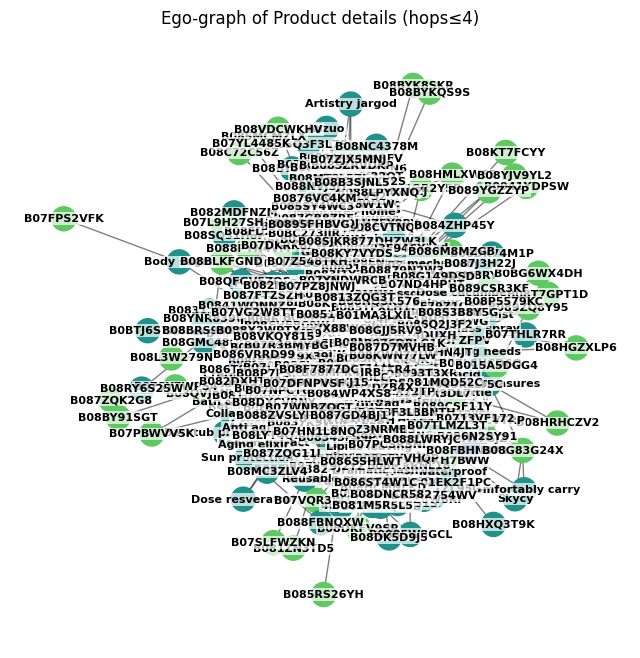

In [236]:
draw_ego_hops(g_tax_error, center_node="Product details", hops=4)

In [245]:
#import pandas as pd
# import networkx as nx
from collections import defaultdict

# Assuming gemma_relation (pd.DataFrame) and g_tax (nx.DiGraph) are loaded from previous cells.
# g_tax: edges represent parent -> child relationship ('is parent of')
print("# Unique relationships: ", len(gemma_relation.drop_duplicates()))

print("\nDetecting redundancies: Items linked to both a taxonomy node and its parent...")

# 1. Filter item relations (head is item ID starting with B0, relation is 'related to', tail is taxonomy node)
# Added check to exclude potential user IDs like 'B0...' followed by '_'
item_relations = gemma_relation[
    (gemma_relation['head'].str.startswith('B0', na=False)) &
    (gemma_relation['relation'] == 'related to') &
    (~gemma_relation['head'].str.contains('_', na=False))
].copy() # Use .copy() to avoid SettingWithCopyWarning if modifying later

# Ensure tail nodes are strings (taxonomy nodes)
item_relations['tail'] = item_relations['tail'].astype(str)

# 2. Group related taxonomy nodes by item
# Use .dropna() in case some items have no relations after filtering
item_groups = item_relations.groupby('head')['tail'].apply(set).dropna()

# 3. Detect redundancies
redundancies_found = []
redundancy_details = defaultdict(list) # Store details: {item: [(parent, child), ...]}

print(f"Checking {len(item_groups)} items with multiple taxonomy links...")

# Check if g_tax exists and is a graph
if 'g_tax_error' not in locals() or not isinstance(g_tax_error, nx.Graph):
    print("Error: Taxonomy graph 'g_tax_error' not found or is not a NetworkX graph.")
    # Handle error appropriately, maybe raise exception or exit
else:
    processed_items = 0
    for item, related_nodes in item_groups.items():
        if len(related_nodes) < 2:
            continue # Need at least two related nodes to have a redundancy

        nodes_list = list(related_nodes)
        item_has_redundancy = False
        # Iterate through all unique pairs of related nodes for the item
        for i in range(len(nodes_list)):
            for j in range(i + 1, len(nodes_list)):
                node1 = nodes_list[i]
                node2 = nodes_list[j]

                # Ensure both nodes exist in the taxonomy graph before checking edges
                if node1 in g_tax and node2 in g_tax:
                    # Check if node1 is parent of node2 in g_tax
                    if g_tax.has_edge(node1, node2):
                        redundancy = (item, node1, node2) # (item, parent, child)
                        # Check for duplicates before adding
                        if (node1, node2) not in redundancy_details[item]:
                             redundancy_details[item].append((node1, node2))
                             item_has_redundancy = True

                    # Check if node2 is parent of node1 in g_tax
                    elif g_tax.has_edge(node2, node1):
                         redundancy = (item, node2, node1) # (item, parent, child)
                         # Check for duplicates before adding
                         if (node2, node1) not in redundancy_details[item]:
                             redundancy_details[item].append((node2, node1))
                             item_has_redundancy = True

        if item_has_redundancy:
            processed_items += 1
            # Collect all unique redundancy tuples (item, parent, child)
            for parent, child in redundancy_details[item]:
                 redundancies_found.append((item, parent, child))


    # 4. Report results
    print(f"\nFinished checking. Found {len(redundancies_found)} redundant relationships across {len(redundancy_details)} items.")
    print(f"% of # relationsships are redundant: {round(len(redundancies_found) / len(gemma_relation) * 100, 2)}") 
    print(f"% of # items with multiple relationsships have redundancies: {round(len(redundancy_details) / len(item_groups) * 100, 2)}") 
    print(f"A redundant relationship means an item is linked to both a parent node and its child node in the taxonomy.")

    # Print some examples
    if redundancies_found:
        print("\nExamples of redundant links (Item, Parent, Child):")
        limit = min(10, len(redundancies_found))
        for i in range(limit):
            item, parent, child = redundancies_found[i]
            print(f"- Item: {item}, Parent: {parent}, Child: {child}")
        if len(redundancies_found) > limit:
            print(f"... and {len(redundancies_found) - limit} more.")

        # Optional: Analyze which parent-child pairs appear most often in redundancies
        parent_child_counts = defaultdict(int)
        for item_redundancies_list in redundancy_details.values():
            for parent, child in item_redundancies_list:
                parent_child_counts[(parent, child)] += 1

        print("\nMost common redundant parent-child pairs:")
        # Sort by count descending
        sorted_pairs = sorted(parent_child_counts.items(), key=lambda pc_item: pc_item[1], reverse=True)
        limit = min(10, len(sorted_pairs))
        for i in range(limit):
            (parent, child), count = sorted_pairs[i]
            print(f"- ({parent}, {child}): Found for {count} items")
        if len(sorted_pairs) > limit:
             print(f"... and {len(sorted_pairs) - limit} more pairs.")
    else:
        print("\nNo redundant relationships found.")


# Unique relationships:  2449

Detecting redundancies: Items linked to both a taxonomy node and its parent...
Checking 297 items with multiple taxonomy links...

Finished checking. Found 723 redundant relationships across 190 items.
% of # relationsships are redundant: 29.52
% of # items with multiple relationsships have redundancies: 63.97
A redundant relationship means an item is linked to both a parent node and its child node in the taxonomy.

Examples of redundant links (Item, Parent, Child):
- Item: B00O2FGBJS, Parent: Perfect skincare, Child: Hydrate
- Item: B00O2FGBJS, Parent: Skin revitalizing, Child: Lotion & Skin Revitalizing
- Item: B00O2FGBJS, Parent: Skin ingredients, Child: Indulge skin
- Item: B00O2FGBJS, Parent: Serum potent, Child: Skin details
- Item: B00O2FGBJS, Parent: Smoother skin, Child: Skin details
- Item: B00TK0VV68, Parent: Perfect skincare, Child: Hydrate
- Item: B00TK0VV68, Parent: Skin revitalizing, Child: Lotion & Skin Revitalizing
- Item: B00TK0VV68, Par